# Práctica 4 - Relación entra las variables Exponencial y Poisson

**Licenciatura en Matemáticas Aplicadas, UAM-C**  
**UEA:** Probabilidad II  
**Trimestre:** 26P  
**Grupo:** CF01MA  
**Profesora** Daniela Aguirre Guerrero

---

## Objetivos


- Simular un proceso de Poisson.
- Verificar que el número de eventos en un intervalo sigue una distribución de Poisson.
- Verificar que los tiempos entre eventos siguen una distribución exponencial.
- Comprobar experimentalmente la relación
$$P(X>a)=P(Y=0)$$

donde:

$X$ es la Variable (continúa) Exponencial que modela el tiempo entre cada evento.

$Y$ es la Variable (discreta) de Poisson que modela el número de eventos ocurridos hasta el tiempo $a$.



## Preparación del entorno


In [60]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

# Ajustes de visualización
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 12

# 1. Distribución Exponencial

La distribución exponencial modela tiempos de espera entre eventos.

Su función de densidad es:

$$
f_X(x)=\lambda e^{-\lambda x}, \quad x \ge 0
$$

donde $\lambda$ es la cantidad de eventos ocurridos por unidad de tiempo (tasa del proceso de Poisson).


## 1.1 Función de densidad de probabilidad de una distribución exponencial

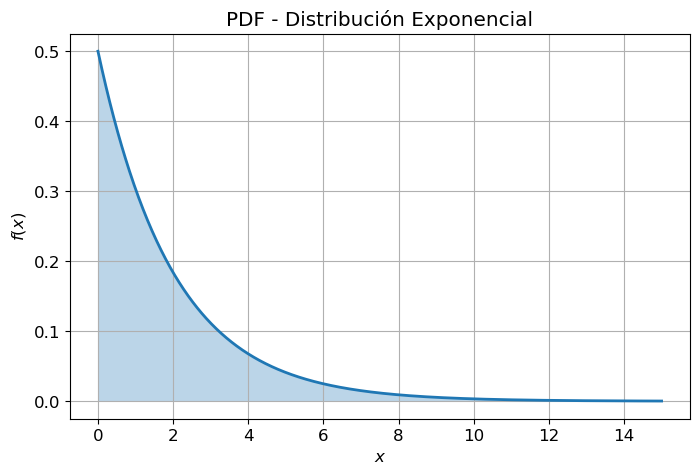

In [63]:
lam = 0.5 # Ocurren 0.5 eventos por unidad de tiempo
#1/lam = 2, cada dos unidades de tiempo, ocurre un evento

X_exp = stats.expon(scale=1/lam) #crea la v.a. exponencial

x = np.linspace(0,15,1000)
pdf_exp = X_exp.pdf(x) #Calcula la función de densidad de probabilidad para un intervalos de 
                        # 1000 valores de 0<x<15

plt.plot(x, pdf_exp, lw=2)
plt.fill_between(x, pdf_exp, alpha=0.3) #rellena

plt.title('PDF - Distribución Exponencial')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.grid()
plt.show()

## 1.2 Función de probabilidad acumulada de una distribución exponencial

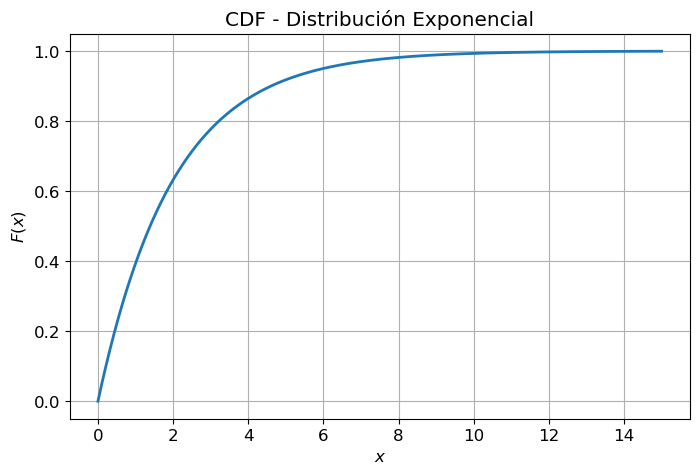

In [64]:
cdf_exp = X_exp.cdf(x)

plt.plot(x, cdf_exp, lw=2)

plt.title('CDF - Distribución Exponencial')
plt.xlabel('$x$')
plt.ylabel('$F(x)$')
plt.grid()
plt.show()

## 1.3 Simulación de tiempos exponenciales

Considera una tasa

$\lambda=2$

eventos por unidad de tiempo.

Generaremos 10 000 tiempos entre eventos.

In [65]:
lam = 2

n = 10000

# Elige 10000 valores de una v.a. exponencial con lambda=2
X_tiempos = np.random.exponential(
    scale=1/lam,
    size=n
)

## 1.4 Gráfica el histrograma de tiempos

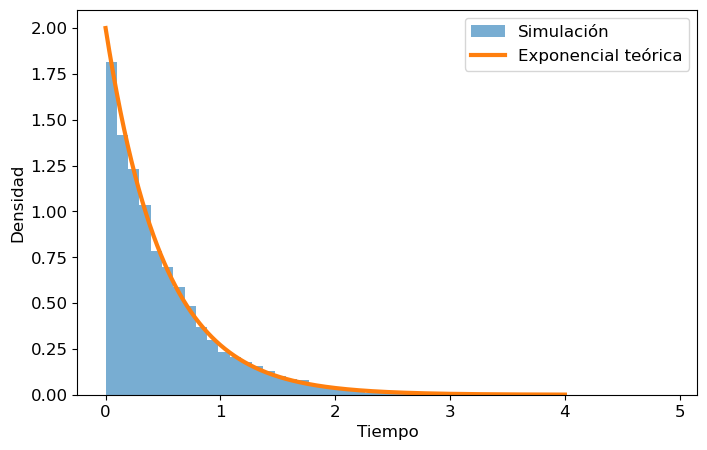

In [67]:
x = np.linspace(0,4,1000)

plt.hist(
    X_tiempos,
    bins=50,
    density=True,
    alpha=0.6,
    label='Simulación'
)

plt.plot(
    x,
    stats.expon.pdf(x,scale=1/lam),
    linewidth=3,
    label='Exponencial teórica'
)

plt.xlabel("Tiempo")
plt.ylabel("Densidad")
plt.legend()
plt.show()

### Pregunta

¿Qué distribución siguen los tiempos entre eventos?

# 2 Construcción de un proceso de Poisson

Los tiempos exponenciales representan los tiempos entre eventos.

Sumándolos obtenemos la cantidad de eventos ocurridos.

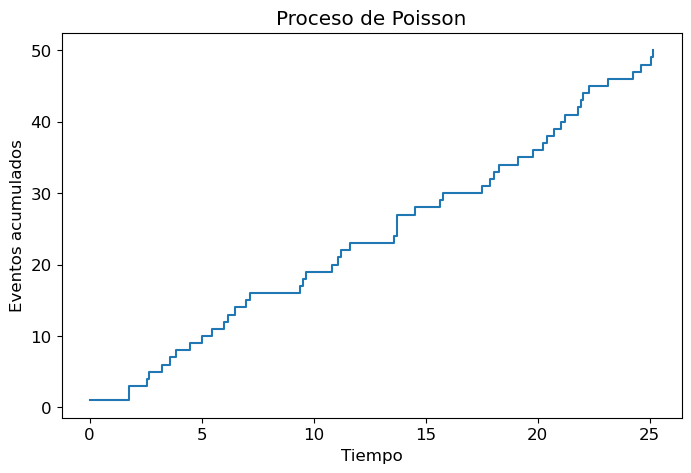

In [69]:
eventos = np.cumsum(X_tiempos)
plt.step(
    eventos[:50],
    np.arange(1,51),
    where='post'
)

plt.xlabel("Tiempo")
plt.ylabel("Eventos acumulados")
plt.title("Proceso de Poisson")
plt.show()

### Pregunta

¿Por qué la gráfica tiene forma de escalera?

## 2.1 Número de eventos en un intervalo

Consideremos intervalos de longitud igual a una unidad de tiempo

$$t=1$$

y contemos cuántos eventos ocurren.

In [70]:
lam = 2 # Los eventos ocurren a una tasa de 2 eventos por unidad de tiempo

muestras = 10000

# La v.a. de Poisson modela el número de eventos en un intervalo de tiempo
# Elige 10000 valores de una v.a. de Poisson con lambda=2
Y_eventos = np.random.poisson(
    lam=lam,
    size=muestras
)

## 2.2 Comparación con la Poisson teórica

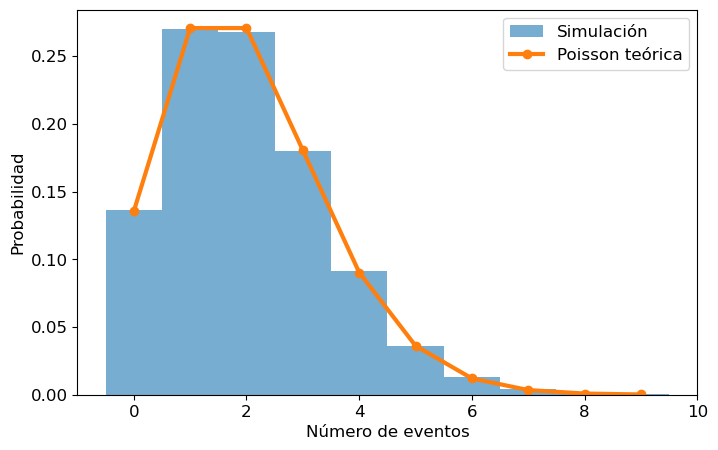

In [59]:
k = np.arange(0,10)

plt.hist(
    Y_eventos,
    bins=np.arange(-0.5,10.5),
    density=True,
    alpha=0.6,
    label='Simulación'
)

plt.plot(
    k,
    poisson.pmf(k,lam), #Función de masa de probabilidad de la v.a. de Poisson
    'o-',
    linewidth=3,
    label='Poisson teórica'
)

plt.xlabel("Número de eventos")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

# 3. La conexión Poisson–Exponencial

Considerando un proceso de Poisson, donde:

$X$ es la Variable Exponencial que modela el tiempo entre cada event,.

$Y$ es la Variable de Poisson que modela el número de eventos ocurridos hasta el tiempo $a$.

Considerando que han pasado $a$ unidades de tiempo y aún no ocurre el primer evento, entonces:

$$P(X>a)=P(Y=0)$$

*La probabilidad de que hayan pasado más de $a$ unidades de tiempo es igual a la probabilidad de que no haya ocurrido ningún evento.*

Verfiquémoslo considerando $a=1$

## 3.1 Probabilidad de que hayan pasado más de $a$ unidades de tiempo

Modelamos con la v.a. Exponencial que aproximamos ( X_tiempos )

In [53]:
a = 1

p_exp_approx = np.mean(X_tiempos > a)

print("P(X_tiempos > a) =", p_exp_approx)

P(X_tiempos > a) = 0.1307


Modelamos con la v.a. Exponencial teórica y con $\lambda=2$

In [71]:
p_exp_teorica = np.exp(-lam*a)
print("P(X > a) =", p_exp_teorica)

P(X > a) = 0.1353352832366127


## 3.2 Probabilidad de que no haya ocurrido ningún evento.

Modelamos con la v.a. de Poisson teórica con parámetro $\lambda=2$

In [72]:
p_pois_teorica = poisson.pmf(0,lam*a)

print("P(Y=0) =", p_pois_teorica)

P(Y=0) = 0.1353352832366127


## 3.3 Verificamos para varios valores de tiempo

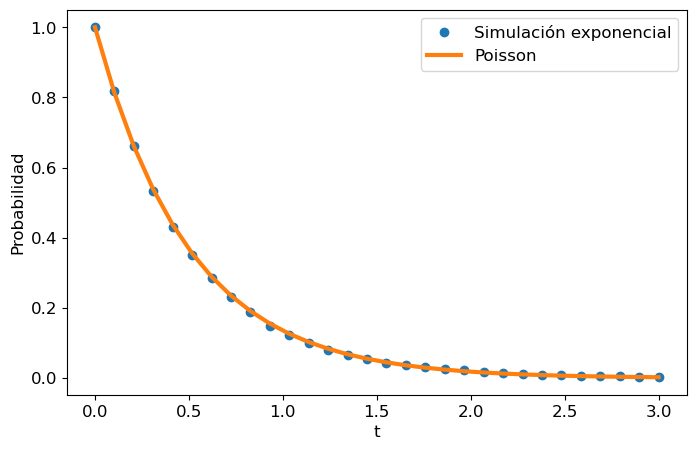

In [58]:
# Linea de tiempo de 0 a 3 con 30 intervalos
ts = np.linspace(0,3,30) 

p_exp = []
p_pois = []

# Por cada punto de la línea de tiempo obtenemos
for t in ts:
    
    # P[X>t] - Usando la v.a. Exponencial aproximada (X_tiempos)
    # Han pasado t unidad de tiempo y no ha ocurrido ningún evento
    p_exp.append(np.mean(X_tiempos > t))
    # P[Y=0] - Usando la v.a. de Poisson teórica con parámetro lambda=2
    p_pois.append(poisson.pmf(0,lam*t))
    
# Gráficamos
plt.plot(
    ts,
    p_exp,
    'o',
    label='Simulación exponencial'
)

plt.plot(
    ts,
    p_pois,
    linewidth=3,
    label='Poisson'
)

plt.xlabel("t")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

## Responde las siguientes preguntas 
Puedes responde a mano o en una celda markdown

1. ¿Por qué los valores de ambas funciones se superponen si fueron generados con distintas variables aleatorias?
2. ¿Qué probabilidad respresenta el eje y?
3. ¿Qué tiempo respresenta el eje x?
4. ¿Está gráfica representa una función de densidad de probabilidad? ¿De qué v.a.?

# 4. Ejercicio de aplicación

Una central telefónica recibe llamadas siguiendo un proceso de Poisson con tasa

$$\lambda=5$$

llamadas por hora.

Usando código en python, gráfica lo siguiente:

- Función de densidad de probabilidad la variable exponencial asociada.
- Función de masa de probabilidad de la variable de poisson asociada.

Usando código en python, calcula lo siguiente:

1. ¿Cuál es la probabilidad de recibir exactamente 3 llamadas en una hora? 
2. ¿Cuál es la probabilidad de esperar más de 30 minutos para la siguiente llamada? 
3. ¿Cuál es la probabilidad de esperar más de 30 minutos para la siguiente llamada, dado que ya esperaste 20 min?

Para el inciso 2, usa código Python para gráfica la función de densidad de probabilidad, sombreando el área correspondiente a la probabilidad solicitada. Para hacerlo puedes revisar el código de prácticas anteriores.

Cálcula manualmente la probabilidades de los incisos 2, 3 y responde

4. Las respuestas de los incisos 2 y 3 deben se iguales, ¿por qué?
5. ¿Explica qué es un proceso de Poisson (con tus propias palabras)?